In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib

from src.models.features import build_dataset, time_series_split
from src.models.xgboost_model import (
    train_xgboost,
    explain_with_shap,
    get_prediction_explanation,
    calibrate_model
)
from src.models.logistic_model import train_logistic
from src.data.database import load_prices

TICKER = "RELIANCE.NS"
print("Imports done.")

C:\Users\devgi\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Imports done.


Building Datasets

In [2]:
X, y, dates = build_dataset(TICKER, horizon=10, threshold=0.0)
X_train, X_test, y_train, y_test = time_series_split(X, y,
                                                       test_size=0.2)
print(f"\nFeatures: {list(X.columns)}")

Dataset built for RELIANCE.NS
  Total samples : 440
  Features      : 13
  UP days       : 206 (46.8%)
  DOWN days     : 234 (53.2%)
  Date range    : 2024-09-12 → 2026-06-19
Train: 352 days (2024-09-12 → 2026-02-10)
Test:  88 days  (2026-02-11 → 2026-06-19)

Features: ['rsi', 'macd', 'macd_signal', 'macd_hist', 'bb_pct', 'bb_width', 'sma_20', 'sma_50', 'ema_20', 'volume_ratio', 'price_vs_sma20', 'price_vs_sma50', 'rsi_normalized']


Training logistic regression baseline

In [3]:
print("="*50)
print("BASELINE: Logistic Regression")
print("="*50)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

scaler         = StandardScaler()
X_tr_scaled    = scaler.fit_transform(X_train)
X_te_scaled    = scaler.transform(X_test)

lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_tr_scaled, y_train)

lr_pred = lr_model.predict(X_te_scaled)
lr_prob = lr_model.predict_proba(X_te_scaled)[:, 1]
lr_acc  = accuracy_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr_prob)

print(f"Logistic — Accuracy: {lr_acc:.4f}  AUC: {lr_auc:.4f}")

BASELINE: Logistic Regression
Logistic — Accuracy: 0.6818  AUC: 0.6931


Training XGBoost

In [4]:
print("="*50)
print("CHALLENGER: XGBoost")
print("="*50)

xgb_model, xgb_metrics = train_xgboost(
    X_train, y_train, X_test, y_test
)

CHALLENGER: XGBoost
Running time-series cross-validation...
  Fold 1: AUC=0.5256  Acc=0.4773  (n_train=88, n_val=88)
  Fold 2: AUC=0.7208  Acc=0.6364  (n_train=176, n_val=88)
  Fold 3: AUC=0.7423  Acc=0.4432  (n_train=264, n_val=88)

  CV AUC : 0.6629 ± 0.0975
  CV Acc : 0.5189 ± 0.0842

Training final model on full training set...

══════════════════════════════════════════════════
  XGBOOST RESULTS (horizon=10)
══════════════════════════════════════════════════
  Accuracy  : 0.5795  (58.0%)
  ROC-AUC   : 0.6908

  Classification Report:
              precision    recall  f1-score   support

        DOWN       0.78      0.50      0.61        58
          UP       0.43      0.73      0.54        30

    accuracy                           0.58        88
   macro avg       0.61      0.62      0.58        88
weighted avg       0.66      0.58      0.59        88

  Confusion Matrix:
               Predicted DOWN  Predicted UP
  Actual DOWN         29              29
  Actual UP            

Head-to-head comparison

In [5]:
always_up_acc = y_test.mean()

print(f"\n{'═'*55}")
print(f"  MODEL COMPARISON (horizon=10 days)")
print(f"{'═'*55}")
print(f"  {'Model':<22} {'Accuracy':>10} {'ROC-AUC':>10}")
print(f"  {'─'*44}")
print(f"  {'Always predict UP':<22} {always_up_acc:>10.4f} {'0.5000':>10}")
print(f"  {'Logistic Regression':<22} {lr_acc:>10.4f} {lr_auc:>10.4f}")
print(f"  {'XGBoost':<22} {xgb_metrics['accuracy']:>10.4f} "
      f"{xgb_metrics['roc_auc']:>10.4f}")
print(f"{'═'*55}")

auc_gain = xgb_metrics['roc_auc'] - lr_auc
print(f"\n  XGBoost improvement over Logistic: +{auc_gain:.4f} AUC")
print(f"  CV AUC: {xgb_metrics['cv_auc_mean']:.4f} "
      f"± {xgb_metrics['cv_auc_std']:.4f}")
print(f"  CV fold AUCs: "
      f"{[round(v,4) for v in xgb_metrics['cv_auc_folds']]}")


═══════════════════════════════════════════════════════
  MODEL COMPARISON (horizon=10 days)
═══════════════════════════════════════════════════════
  Model                    Accuracy    ROC-AUC
  ────────────────────────────────────────────
  Always predict UP          0.3409     0.5000
  Logistic Regression        0.6818     0.6931
  XGBoost                    0.5795     0.6908
═══════════════════════════════════════════════════════

  XGBoost improvement over Logistic: +-0.0023 AUC
  CV AUC: 0.6629 ± 0.0975
  CV fold AUCs: [0.5256, 0.7208, 0.7423]


SHAP explainability

In [6]:
explainer, shap_values = explain_with_shap(
    xgb_model, X_train, X_test
)

# Print top 5 features by mean |SHAP|
import numpy as np
mean_shap = np.abs(shap_values).mean(axis=0)
top5 = sorted(zip(X_test.columns, mean_shap),
               key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 most important features (by mean |SHAP|):")
print(f"{'─'*40}")
for feat, importance in top5:
    bar = "█" * int(importance * 200)
    print(f"  {feat:<22} {importance:.4f}  {bar}")


Computing SHAP values...
  SHAP summary plot saved.
  SHAP importance chart saved.
  SHAP waterfall chart saved.

Top 5 most important features (by mean |SHAP|):
────────────────────────────────────────
  sma_50                 1.4350  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  macd_hist              1.0746  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  macd_signal            0.6848  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  price_vs_sma50         0.5091  █████████████████████████

Today's prediction with explanation

In [7]:
# Most recent row in test set = most recent prediction we can make
today_row   = X_test.iloc[[-1]]
today_date  = X_test.index[-1].date()

explanation = get_prediction_explanation(
    xgb_model, explainer, today_row
)

print(f"\n{'═'*50}")
print(f"  TODAY'S PREDICTION — {today_date}")
print(f"{'═'*50}")
print(f"  P(UP in 10 days)   : {explanation['probability_up']:.1%}")
print(f"  P(DOWN in 10 days) : {explanation['probability_down']:.1%}")
print(f"  Confidence         : {explanation['confidence'].upper()}")
print(f"  Base rate          : {explanation['base_rate']:.4f}")
print(f"\n  Why — top 5 contributing features:")
print(f"  {'Feature':<22} {'Direction':<10} {'Contribution':>12}")
print(f"  {'─'*46}")
for f in explanation["top_features"]:
    sign = "+" if f["shap_value"] > 0 else ""
    bar  = "▲" if f["direction"] == "bullish" else "▼"
    print(f"  {f['feature']:<22} {bar} {f['direction']:<8} "
          f"{sign}{f['shap_value']:>10.4f}")


══════════════════════════════════════════════════
  TODAY'S PREDICTION — 2026-06-19
══════════════════════════════════════════════════
  P(UP in 10 days)   : 30.2%
  P(DOWN in 10 days) : 69.8%
  Confidence         : MEDIUM
  Base rate          : -0.0028

  Why — top 5 contributing features:
  Feature                Direction  Contribution
  ──────────────────────────────────────────────
  macd_hist              ▼ bearish     -1.6362
  macd_signal            ▲ bullish  +    0.9960
  price_vs_sma50         ▼ bearish     -0.4410
  volume_ratio           ▲ bullish  +    0.4210
  sma_20                 ▼ bearish     -0.3773


Probability calibration

In [8]:
calibrated_model = calibrate_model(
    xgb_model, X_train, y_train, X_test, y_test
)

# Compare raw vs calibrated probabilities on a few samples
raw_probs = xgb_model.predict_proba(X_test)[:, 1]
cal_probs = calibrated_model.predict_proba(X_test)[:, 1]

print("\nRaw vs Calibrated probabilities (first 10 test samples):")
print(f"{'Date':<14} {'Raw P(UP)':>10} {'Cal P(UP)':>10} {'Actual':>8}")
print(f"{'─'*46}")
for i in range(min(10, len(X_test))):
    date   = X_test.index[i].date()
    actual = "UP" if y_test.iloc[i] == 1 else "DOWN"
    print(f"{str(date):<14} {raw_probs[i]:>10.4f} "
          f"{cal_probs[i]:>10.4f} {actual:>8}")

  Calibration curve saved.

  Calibration check (first 5 test samples):
   Raw P(UP)  Cal P(UP)   Actual
  ──────────────────────────────
      0.0154     0.1325     DOWN
      0.0242     0.1368     DOWN
      0.0435     0.1467     DOWN
      0.0201     0.1348     DOWN
      0.0224     0.1359     DOWN

  Calibrated model saved.

Raw vs Calibrated probabilities (first 10 test samples):
Date            Raw P(UP)  Cal P(UP)   Actual
──────────────────────────────────────────────
2026-02-11         0.0154     0.1325     DOWN
2026-02-12         0.0242     0.1368     DOWN
2026-02-13         0.0435     0.1467     DOWN
2026-02-16         0.0201     0.1348     DOWN
2026-02-17         0.0224     0.1359     DOWN
2026-02-18         0.0098     0.1298     DOWN
2026-02-19         0.0310     0.1402     DOWN
2026-02-20         0.0777     0.1656       UP
2026-02-23         0.0330     0.1413     DOWN
2026-02-24         0.0220     0.1357     DOWN


Strategy backtest comparison

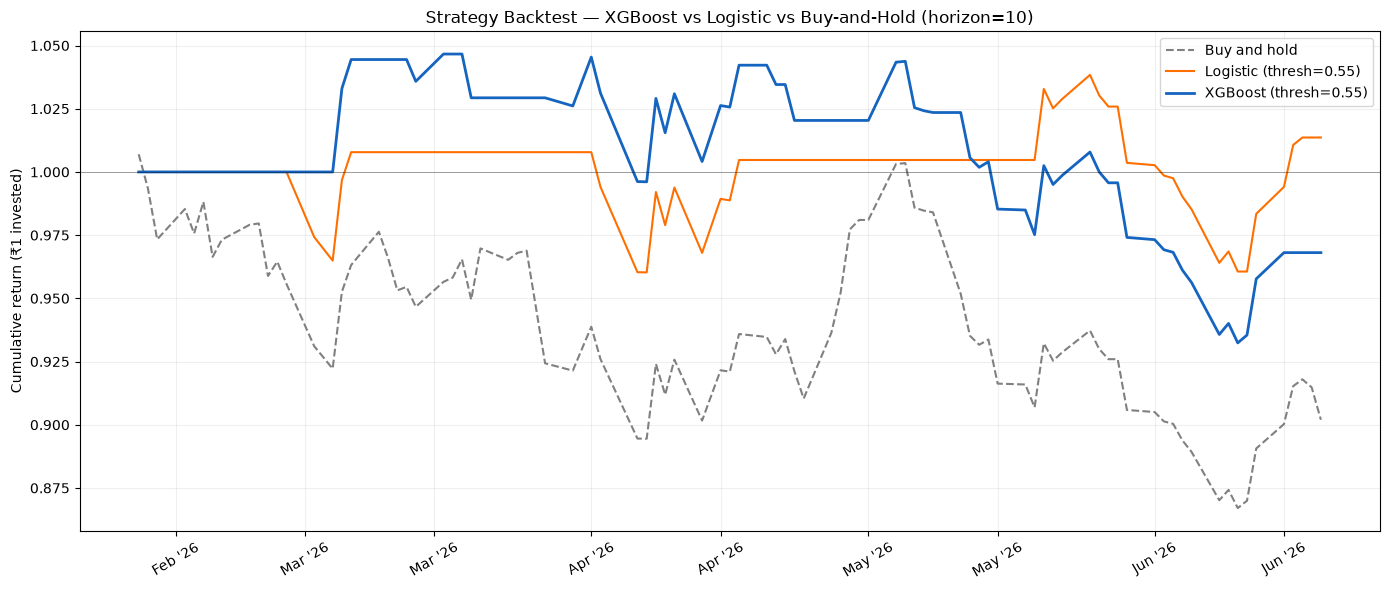


Final returns over test period:
  Buy and hold  : -9.80%
  Logistic      : +1.36%
  XGBoost       : -3.19%


In [9]:
prices       = load_prices(TICKER)
test_dates   = X_test.index
price_returns= prices["Close"].pct_change().reindex(
    test_dates
).fillna(0)

# Strategy: invest when model says P(UP) > threshold
threshold = 0.55

lr_position  = (lr_prob > threshold).astype(float)
xgb_position = (xgb_metrics["y_pred_proba"] > threshold).astype(float)

cum_bh  = (1 + price_returns).cumprod()
cum_lr  = (1 + lr_position  * price_returns).cumprod()
cum_xgb = (1 + xgb_position * price_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, cum_bh,  color="gray",    lw=1.5,
        linestyle="--", label="Buy and hold")
ax.plot(test_dates, cum_lr,  color="#FF6F00", lw=1.5,
        label=f"Logistic (thresh={threshold})")
ax.plot(test_dates, cum_xgb, color="#1565C0", lw=2,
        label=f"XGBoost (thresh={threshold})")
ax.axhline(1.0, color="black", lw=0.6, alpha=0.4)
ax.set_title(
    f"Strategy Backtest — XGBoost vs Logistic vs Buy-and-Hold "
    f"(horizon=10)",
    fontsize=12
)
ax.set_ylabel("Cumulative return (₹1 invested)")
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../data/charts/strategy_backtest.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFinal returns over test period:")
print(f"  Buy and hold  : {cum_bh.iloc[-1]-1:+.2%}")
print(f"  Logistic      : {cum_lr.iloc[-1]-1:+.2%}")
print(f"  XGBoost       : {cum_xgb.iloc[-1]-1:+.2%}")

Summary

In [10]:
print(f"\n{'═'*55}")
print(f"  WEEK 5 COMPLETE — KEY NUMBERS FOR YOUR RESUME")
print(f"{'═'*55}")
print(f"  Model            : XGBoost (300 trees, max_depth=4)")
print(f"  Prediction target: {TICKER} direction in 10 trading days")
print(f"  Test AUC         : {xgb_metrics['roc_auc']:.4f}")
print(f"  Test Accuracy    : {xgb_metrics['accuracy']:.1%}")
print(f"  CV AUC           : {xgb_metrics['cv_auc_mean']:.4f} "
      f"± {xgb_metrics['cv_auc_std']:.4f}")
print(f"  vs Logistic AUC  : {lr_auc:.4f} "
      f"(+{xgb_metrics['roc_auc']-lr_auc:.4f} improvement)")
print(f"  vs Always-UP     : {always_up_acc:.4f} accuracy baseline")
print(f"\n  Saved files:")
print(f"    models/xgboost_model.pkl")
print(f"    models/xgboost_calibrated.pkl")
print(f"    data/charts/shap_summary.png")
print(f"    data/charts/shap_importance.png")
print(f"    data/charts/shap_waterfall.png")
print(f"    data/charts/calibration_curve.png")
print(f"    data/charts/strategy_backtest.png")


═══════════════════════════════════════════════════════
  WEEK 5 COMPLETE — KEY NUMBERS FOR YOUR RESUME
═══════════════════════════════════════════════════════
  Model            : XGBoost (300 trees, max_depth=4)
  Prediction target: RELIANCE.NS direction in 10 trading days
  Test AUC         : 0.6908
  Test Accuracy    : 58.0%
  CV AUC           : 0.6629 ± 0.0975
  vs Logistic AUC  : 0.6931 (+-0.0023 improvement)
  vs Always-UP     : 0.3409 accuracy baseline

  Saved files:
    models/xgboost_model.pkl
    models/xgboost_calibrated.pkl
    data/charts/shap_summary.png
    data/charts/shap_importance.png
    data/charts/shap_waterfall.png
    data/charts/calibration_curve.png
    data/charts/strategy_backtest.png
